# <span style="color: rgba(230, 0, 126, 1);"> BANK MARKETING </span> #

### <span style="color: rgba(230, 0, 126, 1);"> 1.- Importación de librerias para el análisis de datos </span> ###

In [34]:
# importación de librerias para el análisis de datos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### <span style="color: rgba(230, 0, 126, 1);"> 2.- Carga de datos desde MySQL </span> ###

In [35]:
# conectar con MySQL utilizando sqlalchemy
from sqlalchemy import create_engine

host = '212.227.90.6'
database = 'Equip_18'
user = 'Equipo18'
password = 'E1q2u3i4p5o18'

# crear la engine para la conexión
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{database}")

# conectar con la BBDD
connection = engine.connect()

# cargar la tabla BANK_marketing como un df
df = pd.read_sql_table('BANK_marketing03112025', connection)

connection.close()

### <span style="color: rgba(230, 0, 126, 1);"> 3.- Exploración de los datos cargados </span> ###

In [36]:
# conocer la dimensión de la tabla y a la vez tener una idea del nombre de los atributos-campos- y valores de los registros-filas-
print(df.shape)
df.head()

(16172, 18)


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [37]:
# conocer que variables son numéricas y que variables son categóricas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16172 entries, 0 to 16171
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         16172 non-null  int64  
 1   age        16159 non-null  float64
 2   job        16172 non-null  object 
 3   marital    16164 non-null  object 
 4   education  16160 non-null  object 
 5   default    16172 non-null  object 
 6   balance    16172 non-null  int64  
 7   housing    16152 non-null  object 
 8   loan       16172 non-null  object 
 9   contact    16172 non-null  object 
 10  day        16172 non-null  int64  
 11  month      16172 non-null  object 
 12  duration   16172 non-null  int64  
 13  campaign   16172 non-null  int64  
 14  pdays      16172 non-null  int64  
 15  previous   16172 non-null  int64  
 16  poutcome   16172 non-null  object 
 17  deposit    16172 non-null  object 
dtypes: float64(1), int64(7), object(10)
memory usage: 2.2+ MB


### <span style="color: rgba(230, 0, 126, 1);"> 4.- Limpieza de datos </span> ###
Situaciones más comunes:
- Datos que faltan en algunas celdas.
- Columnas que no aporten información para el análisis que estamos realizando.
- Filas repetidas.
- Outliers en caso de variables numéricas. No siempre deben ignorarse.
- Errores tipográficos en caso de variables categóricas.

<span style="color: rgba(230, 0, 126, 1);"> 4.1-Filas repetidas </span>

In [38]:
# hay un método que elimina directamente las filas repetidas:
print(f'Tamaño antes de eliminar filas repetidas: {df.shape}')
df.drop_duplicates(inplace=True)
print(f'Tamaño después de eliminar filas repetidas: {df.shape}')

Tamaño antes de eliminar filas repetidas: (16172, 18)
Tamaño después de eliminar filas repetidas: (16162, 18)


<span style="color: rgba(230, 0, 126, 1);"> 4.2-Datos que faltan en algunas celdas  </span>

In [39]:
# para comprobar si faltan datos en algunas celdas es interesante ayudarse del método df.info() y comprobar que todos los campos tengan el mismo número de entradas.
# en el caso de este data set son 11162 valores para cada columna, incluído el título del campo, excepto los campos:
# marital (11157) y education (11155)

# si fuesen pocos registros los que tienen datos faltantes podríamos prescindir de ellos si el % frente al total fuese bajo.
# df.dropna(inplace=True)  # elimina cada fila que al menos contenga un campo vacío.

In [ ]:
# otro método es mediante los métodos isna() combinado con any().
# isna() devuelve un df en la que los valores faltantes aparecen como True y el resto false.
# combinado con any() devuelve la agrupación por columnas y asigna True a aquellas que mínimo tienen un valor nulo.
df.isna().any()

# si fuesen pocos registros los que tienen datos faltantes podríamos prescindir de ellos si el % frente al total fuese bajo.
# df.dropna(inplace=True)  # elimina cada fila que al menos contenga un campo vacío.

In [41]:
# otro método es mediante los métodos isna() combinado con sum().
# isna() devuelve un df en la que los valores faltantes aparecen como True y el resto false.
# combinado con sum() nos indica cuantos datos nulos hay por columna.
df.isna().sum()

# si fuesen pocos registros los que tienen datos faltantes podríamos prescindir de ellos si el % frente al total fuese bajo.
# df.dropna(inplace=True)  # elimina cada fila que al menos contenga un campo vacío.

id            0
age          13
job           0
marital       8
education    12
default       0
balance       0
housing      20
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
deposit       0
dtype: int64

In [ ]:
# para filtrar todas las filas que contienen al menos un valor nulo.
# el parámetro axis=1 indica que se evalúe por fila (en lugar de por columna).
df[df.isna().any(axis=1)]

# si fuesen pocos registros los que tienen datos faltantes podríamos prescindir de ellos si el % frente al total fuese bajo.
# df.dropna(inplace=True)  # elimina cada fila que al menos contenga un campo vacío.

In [43]:
# para realizar el siguiente paso de la imputación cambiaremos los unknown de las columnas de interés a NaN
df['education'] = df['education'].replace('unknown', np.nan)
df['job'] = df['job'].replace('unknown', np.nan)


In [44]:
df.isna().sum()

id             0
age           13
job           96
marital        8
education    738
default        0
balance        0
housing       20
loan           0
contact        0
day            0
month          0
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
deposit        0
dtype: int64

<span style="color: rgba(230, 0, 126, 1);"> 4.3-Imputación de nulos  </span>

In [ ]:
# Optamos por imputar las variables con nulos aplicando el valor más probable para la variable y más relación con el resto de categorías correlacionadas

In [46]:
# IMPUTACIÓN DE EDAD Y CREACIÓN DE RANGOS ETARIOS
# age (vble numérica continua): puede imputarse con mediana condicionada ( a otras relaciones/grupos)

# mediana de edad por grupo 
median_age = (
    df.groupby(['job', 'marital'])['age']
      .median()
      .reset_index()
      .rename(columns={'age':'median_age'})
)

df = df.merge(median_age, on=['job', 'marital'], how='left')

# Imputar los nulos de 'age' con la mediana de su grupo
df['age'] = df['age'].fillna(df['median_age'])

df.drop(columns='median_age', inplace=True)

#df.age.isnull().sum()


In [47]:
# crear columna adicional agrupando las edades 

def age_groups(x):

    '''Clasifica el valor de edad numérico dentro de un rango
       ----------
       Parámetro
       x : float - Edad de una persona.
       -------
       Retorna        
       Grupo de edad correspondiente según los siguientes rangos:
       - '18 - 25' : si la edad es menor o igual a 25
       - '26 - 35' : si la edad está entre 26 y 35
       - '36 - 45' : si la edad está entre 36 y 45
       - '46 - 55' : si la edad está entre 46 y 55
       - '56 - 65' : si la edad está entre 56 y 65
       - '66 +'    : si la edad es mayor a 65'''

    if x <= 25:
        return '18 - 25'
    elif x <= 35:
        return '26 - 35'
    elif x <= 45:
        return '36 - 45'
    elif x <= 55:
        return '46 - 55'
    elif x <= 65:
        return '56 - 65'
    else:
        return '66 + '
    
# Crear una nueva columna 'age_group' aplicando la función age_groups a la columna 'age'
df['age_group'] = df['age'].apply(age_groups)

In [48]:
#IMPUTACIÓN DE EDUCATION (categoría: primary / secondary / tertiary)

# Crosstab con probabilidades condicionales
prob_edu = (
    pd.crosstab([df['job'], df['age_group']], df['education'], normalize='index')
    .round(2))

#prob_edu.head(10)

In [49]:
#Encontrar el nivel más probable para cada combinación
prob_edu['mas_probable_edu'] = prob_edu.idxmax(axis=1)

# Convertir a dataframe para merge
prob_edu_reset = prob_edu.reset_index()[['job', 'age_group', 'mas_probable_edu']]

# Merge con el dataset original
df = df.merge(prob_edu_reset, on=['job', 'age_group'], how='left')

# Imputar nulos con el valor más probable
df.loc[df['education'].isna(), 'education'] = df.loc[df['education'].isna(), 'mas_probable_edu']

# Eliminar columnas auxiliares y rellenar remanentes con la moda global
df.drop(columns=['mas_probable_edu'], inplace=True)

df['education'].fillna(df['education'].mode()[0], inplace=True)


C:\Users\tinke\AppData\Local\Temp\ipykernel_7912\1096683627.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['education'].fillna(df['education'].mode()[0], inplace=True)


In [50]:
#IMPUTACIÓN HOUSING

# Crosstab con probabilidades condicionales

prob_housing = (
    pd.crosstab([df['job'], df['age_group'], df['education'], df['marital']], df['housing'], normalize='index')
    .round(2))

# Asignar el valor de housing más probable por combinación
prob_housing['mas_probable_housing'] = prob_housing.idxmax(axis=1)

# Convertir a dataframe para merge
prob_housing_reset = prob_housing.reset_index()[['job', 'age_group', 'education', 'marital', 'mas_probable_housing']]

# Merge con el dataset
df = df.merge(prob_housing_reset, on=['job', 'age_group', 'education', 'marital'], how='left')

# Imputar nulos con el valor más probable
df.loc[df['housing'].isna(), 'housing'] = df.loc[df['housing'].isna(), 'mas_probable_housing']

# Eliminar columnas auxiliares y rellenar con la moda global
df.drop(columns=['mas_probable_housing'], inplace=True)
df['housing'].fillna(df['housing'].mode()[0], inplace=True)


C:\Users\tinke\AppData\Local\Temp\ipykernel_7912\3244306019.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['housing'].fillna(df['housing'].mode()[0], inplace=True)


In [ ]:
#IMPUTACIÓN DE JOB 

# Crosstab con probabilidades condicionales
prob_job = (
    pd.crosstab([df['education'], df['age_group']], df['job'], normalize='index')
    .round(2))

#Encontrar el nivel más probable para cada combinación
prob_job['mas_probable_job'] = prob_job.idxmax(axis=1)

# Convertir a dataframe para merge
prob_job_reset = prob_job.reset_index()[['education', 'age_group', 'mas_probable_job']]

# Merge con el dataset original
df = df.merge(prob_job_reset, on=['education', 'age_group'], how='left')

# Imputar nulos con el valor más probable
df.loc[df['job'].isna(), 'job'] = df.loc[df['job'].isna(), 'mas_probable_job']

# Eliminar columnas auxiliares y rellenar remanentes con la moda global
df.drop(columns=['mas_probable_job'], inplace=True)

df['job'].fillna(df['job'].mode()[0], inplace=True)

In [ ]:
#IMPUTACIÓN DE MARITAL 

# Crosstab con probabilidades condicionales
prob_marital = (
    pd.crosstab([df['job'], df['age_group']], df['marital'], normalize='index')
    .round(2))

#Encontrar el nivel más probable para cada combinación
prob_marital['mas_probable_marital'] = prob_marital.idxmax(axis=1)

# Convertir a dataframe para merge
prob_marital_reset = prob_marital.reset_index()[['job', 'age_group', 'mas_probable_marital']]

# Merge con el dataset original
df = df.merge(prob_marital_reset, on=['job', 'age_group'], how='left')

# Imputar nulos con el valor más probable
df.loc[df['marital'].isna(), 'marital'] = df.loc[df['marital'].isna(), 'mas_probable_marital']

# Eliminar columnas auxiliares y rellenar remanentes con la moda global
df.drop(columns=['mas_probable_marital'], inplace=True)

df['marital'].fillna(df['marital'].mode()[0], inplace=True)

In [53]:
df.isnull().sum()

id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
age_group    0
dtype: int64

<span style="color: rgba(230, 0, 126, 1);"> 4.4-Columnas que no aporten información para el análisis que estamos realizando.  </span>
- Columnas que no contienen información relevante para nuestro análisis.
- Columnas categóricas con un único valor (o nivel).
- Columnas numéricas con un único valor.
- Columnas con información redundante (por ejemplo 4 columnas para indicar una fecha: dia, mes, año, dia-mes-año).

In [ ]:
# para saber que campos son categóricos y que campos son numéricos
df.info()

In [55]:
# como contar los niveles que tienen cada uno de los campos categóricos:
# .nunique() devuelve el número de valores únicos (distintos) en cada columna.

for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f'En la columna {col} los valores únicos son: {df[col].unique()}')

En la columna job los valores únicos son: ['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'self-employed' 'student']
En la columna marital los valores únicos son: ['married' 'single' 'divorced']
En la columna education los valores únicos son: ['secondary' 'tertiary' 'primary']
En la columna default los valores únicos son: ['no' 'yes']
En la columna housing los valores únicos son: ['yes' 'no']
En la columna loan los valores únicos son: ['no' 'yes']
En la columna contact los valores únicos son: ['unknown' 'cellular' 'telephone']
En la columna month los valores únicos son: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
En la columna poutcome los valores únicos son: ['unknown' 'other' 'failure' 'success']
En la columna deposit los valores únicos son: ['yes' 'no']
En la columna age_group los valores únicos son: ['56 - 65' '36 - 45' '46 - 55' '26 - 35' '18 - 25' '66 + ']


In [56]:
# como saber si un campo numérico tiene más de un valor distinto:
# si la desviación estandard (std) de una columna es 0 quiere decir que los valores de esa columna son todos exactamente igual.
df.describe().round(2)

,id,age,balance,day,duration,campaign,pdays,previous
count,16162.00,16162.00,16162.00,16162.00,16162.00,16162.00,16162.00,16162.00
mean,9696.71,41.31,1535.30,15.67,370.81,2.51,51.42,0.83
std,6754.51,11.93,3292.26,8.44,347.47,2.74,109.47,2.29
min,1.00,18.00,-6847.00,1.00,2.00,1.00,-1.00,0.00
25%,4041.25,32.00,124.00,8.00,137.00,1.00,-1.00,0.00
50%,8081.50,39.00,556.00,15.00,254.00,2.00,-1.00,0.00
75%,17342.75,49.00,1708.00,22.00,494.00,3.00,9.00,1.00
max,21383.00,95.00,81204.00,31.00,3881.00,63.00,854.00,58.00


<span style="color: rgba(230, 0, 126, 1);"> 4.5-Outliers </span>

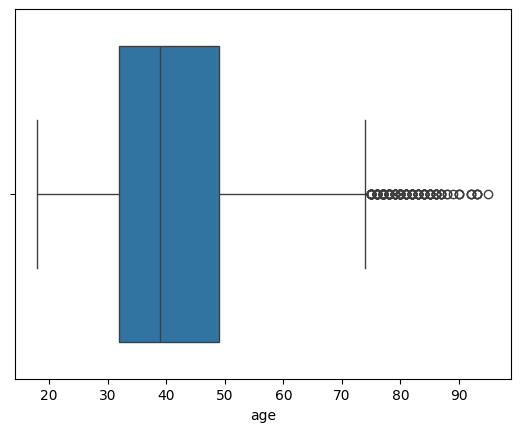

In [58]:
# outlier age (edad del cliente)
sns.boxplot(data=df, x="age")

# según describe(), el valor mínimo de age es 0 y el máximo 95. En este caso podríamos considerar que los valores 0 no son correctos.
# los podríamos sustituir por un valor fijo, o por ejemplo por la media del resto de valores.

# valor fijo:
#df['age']=df['age'].replace(0,35)
#df.describe()

# media del resto de valores sin considerar los 0 que hayan
ageSinCeros=df[df['age']!=0]['age']
mediaAge=ageSinCeros.mean().round(2)
df['age']=df['age'].replace(0,mediaAge)

<Axes: xlabel='balance'>

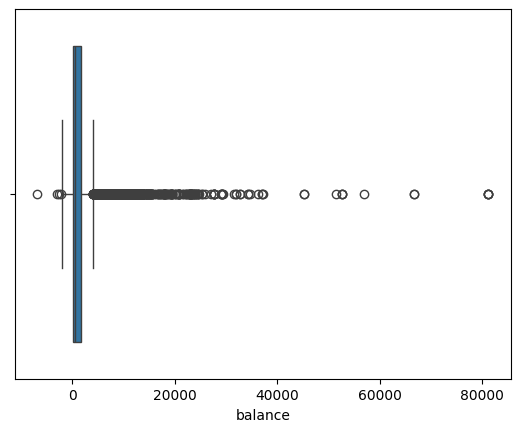

In [59]:
# outlier balance (saldo medio anual del cliente: puede ser negativo o positivo)
sns.boxplot(data=df, x="balance")

<Axes: xlabel='day'>

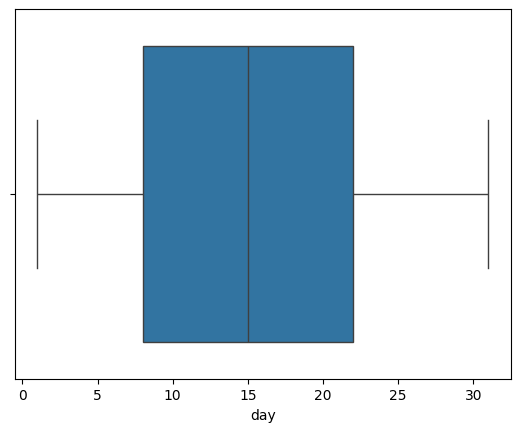

In [60]:
# outlier day (último día de la semana que se contacta con el cliente: de 1 a 31)
sns.boxplot(data=df, x="day")

<Axes: xlabel='duration'>

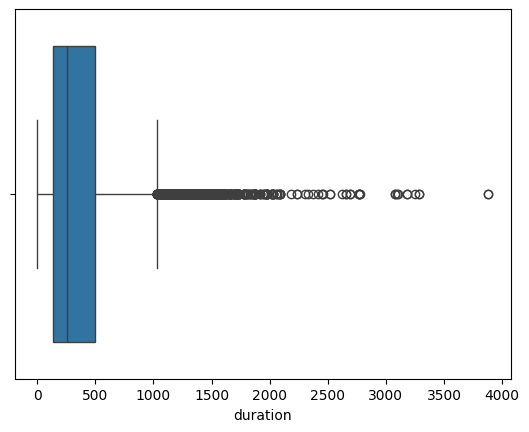

In [61]:
# outlier duration (duración en seg. del último contacto telefónico con el cliente. Si es 0 entonces la variable y debe ser 0)
sns.boxplot(data=df, x="duration")

# convertir los segundos a minutos.
# sobre la misma columna:
# df['duration']=df['duration']/60

# generando el calculo en una nueva columna:
# df.insert(13,'durationMin',df['duration']/60)
# df.describe()

<Axes: xlabel='campaign'>

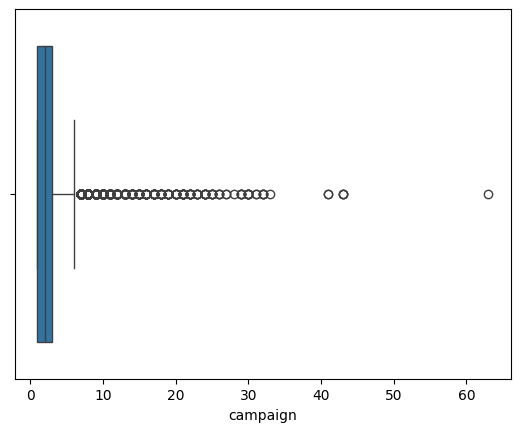

In [62]:
# outlier campaign (número de llamadas para esta campaña)
sns.boxplot(data=df, x="campaign")

# buscar si hay algún patrón con los contactados más de 10 veces?
# df.loc[df['campaign']>10]

# para eliminar registros a partir de un determinado valor
# print(f'Tamaño antes de eliminar filas repetidas: {df.shape}')
# df=df[df['campaign']>10]
# print(f'Tamaño después de eliminar filas repetidas: {df.shape}')

<Axes: xlabel='pdays'>

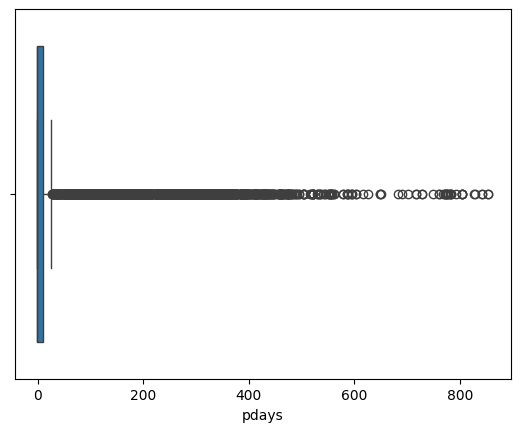

In [63]:
# outlier pdays (días transcurridos desde la última llamada al cliente en campañas anteriores. si es -1 significa que no se contactó previamente con el cliente)
sns.boxplot(data=df, x="pdays")

<Axes: xlabel='previous'>

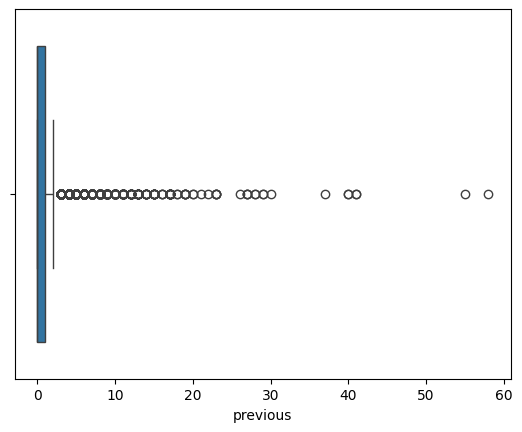

In [64]:
# outlier previous (contactos realizados para campañas anteriores al cliente)
sns.boxplot(data=df, x="previous")

<span style="color: rgba(230, 0, 126, 1);"> 4.6-Errores tipográficos en caso de variables categóricas </span>

In [ ]:
# gráficas de barras para las variables categóricas y comprobar si hay valores similares escritos diferente y cuanto aparecen en el data set
df.info()

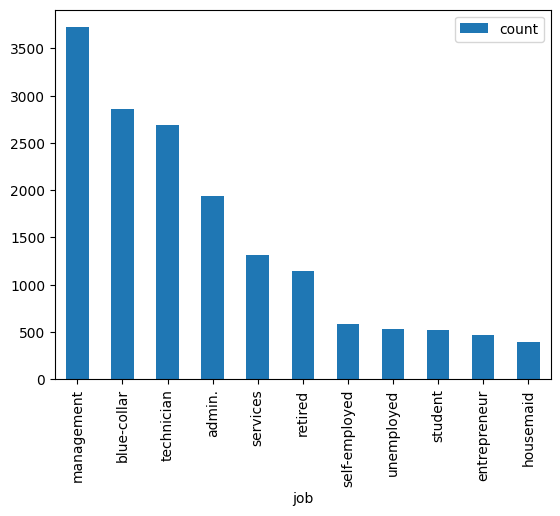

In [66]:
# gráficas de barras para job (trabajo del usuario)
pd.DataFrame(df["job"].value_counts()).plot.bar()

# quizás reemplazar el único trabajo abreviado admin. por administration
df['job']=df['job'].str.replace('admin.','administrative',regex=False)

<Axes: xlabel='marital'>

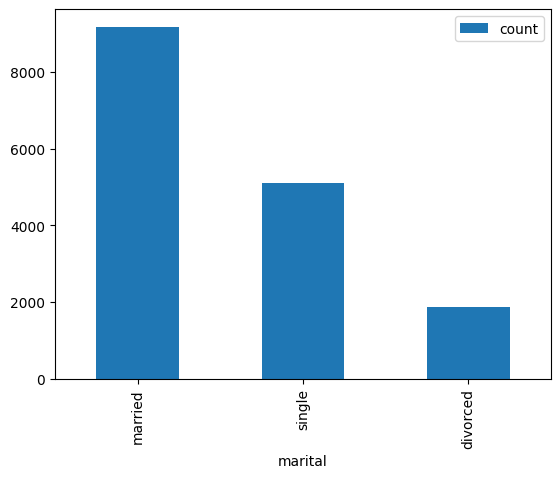

In [67]:
# gráficas de barras para marital (estado civil del usuario)
pd.DataFrame(df["marital"].value_counts()).plot.bar() 

<Axes: xlabel='education'>

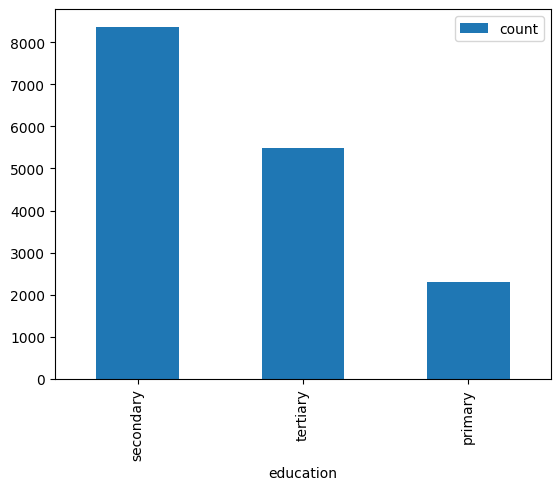

In [68]:
# gráficas de barras para education (nivel de educación del usuario)
pd.DataFrame(df["education"].value_counts()).plot.bar() 

<Axes: xlabel='default'>

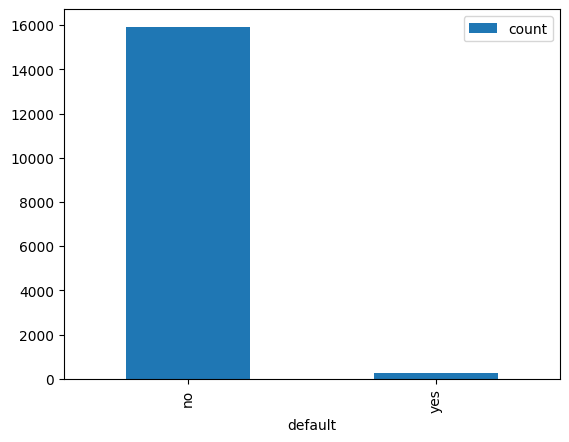

In [69]:
# gráficas de barras para default (indica si el usuario tiene créditos impagados)
pd.DataFrame(df["default"].value_counts()).plot.bar() 

<Axes: xlabel='housing'>

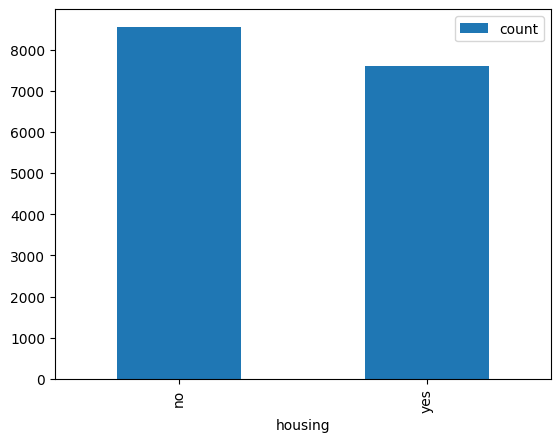

In [70]:
# gráficas de barras para housing (indica si el usuario tiene un crédito de vivienda)
pd.DataFrame(df["housing"].value_counts()).plot.bar() 

<Axes: xlabel='loan'>

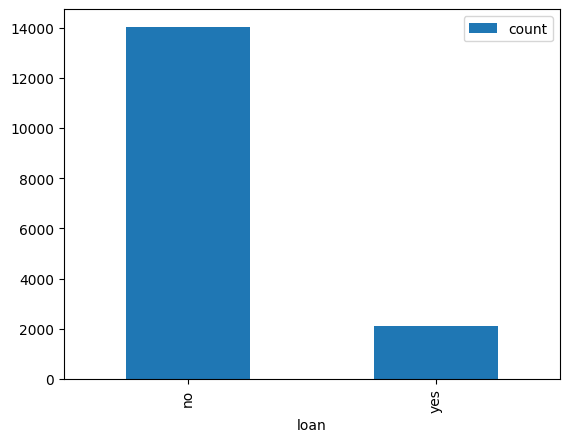

In [71]:
# gráficas de barras para loan (indica si el usuario tiene un crédito personal)
pd.DataFrame(df["loan"].value_counts()).plot.bar() 

<Axes: xlabel='contact'>

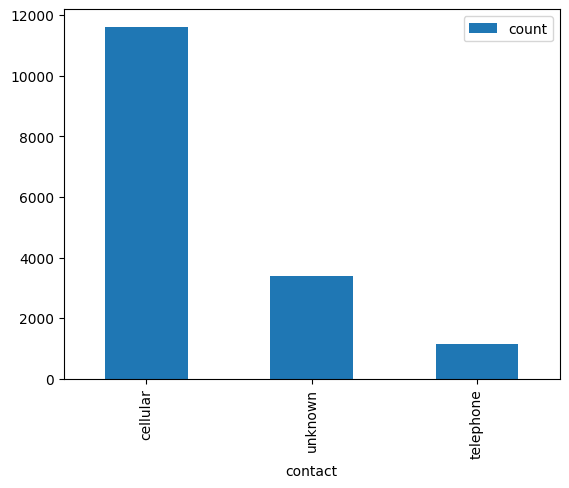

In [72]:
# gráficas de barras para contact (forma de contacto con el usuario)
pd.DataFrame(df["contact"].value_counts()).plot.bar() 

<Axes: xlabel='month'>

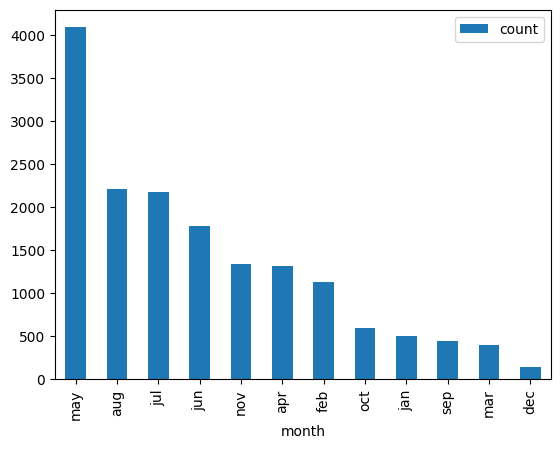

In [73]:
# gráficas de barras para month (mes en el que se realizó el último contacto con el usuario)
pd.DataFrame(df["month"].value_counts()).plot.bar() 

<Axes: xlabel='poutcome'>

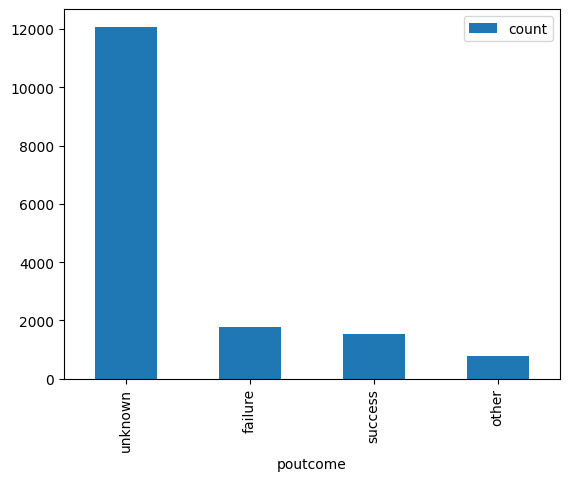

In [74]:
# gráficas de barras para poutcome (resultado de la campaña de marketing anterior a la actual)
pd.DataFrame(df["poutcome"].value_counts()).plot.bar() 

<Axes: xlabel='deposit'>

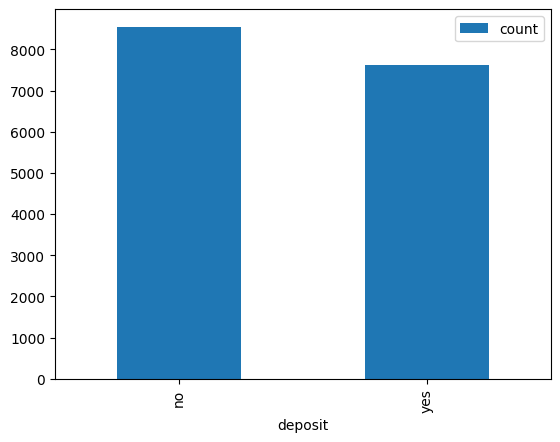

In [75]:
# gráficas de barras para deposit (indica si el usuario ha contratado un depósito a plazo fijo)
pd.DataFrame(df["deposit"].value_counts()).plot.bar() 

### <span style="color: rgba(230, 0, 126, 1);"> 5.- Exportación a csv </span> ###

In [76]:
df.to_csv(r"C:\Users\tinke\Desktop\simulador empresarial\031125dataset.csv",sep=";",index=False)